In [1]:
import warnings
warnings.filterwarnings("ignore")

import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests


patient_programs = pd.read_csv(
    "data/outputs/validated_patient_programs.csv",
    index_col=0
)

program_features = pd.read_csv(
    "data/outputs/validated_program_features.csv",
    index_col=0
)

print(patient_programs.shape)
print(program_features.shape)

(138, 10)
(10, 3465)


In [2]:
adata = sc.read_h5ad(
    "data/IntegratedAtlas.h5ad",
    backed="r"
)


metadata = (
    adata.obs[["donor_id", "disease"]]
    .drop_duplicates()
    .set_index("donor_id")
)


patient_df = patient_programs.join(
    metadata,
    how="inner"
)


print(patient_df.shape)
patient_df["disease"].value_counts()

(138, 11)


disease
breast cancer                                                             51
invasive ductal breast carcinoma                                          47
estrogen-receptor positive breast cancer                                  15
triple-negative breast carcinoma                                          13
HER2 positive breast carcinoma                                             3
invasive lobular breast carcinoma                                          3
breast carcinoma                                                           2
invasive tubular breast carcinoma || invasive lobular breast carcinoma     1
breast apocrine carcinoma                                                  1
breast mucinous carcinoma                                                  1
metaplastic breast carcinoma                                               1
Name: count, dtype: int64

In [4]:
# Identify NMF program columns

programs = [
    c for c in patient_df.columns
    if c != "disease"
]

print("Programs detected:", programs)


results = []

for program in programs:

    groups = [
        patient_df.loc[
            patient_df["disease"] == disease,
            program
        ].values
        for disease in patient_df["disease"].unique()
    ]

    # remove empty groups
    groups = [
        g for g in groups
        if len(g) > 0
    ]

    stat, p = kruskal(*groups)

    results.append(
        [
            program,
            stat,
            p
        ]
    )


results = pd.DataFrame(
    results,
    columns=[
        "Program",
        "Statistic",
        "pvalue"
    ]
)


results["FDR"] = multipletests(
    results["pvalue"],
    method="fdr_bh"
)[1]


results.sort_values("FDR")

Programs detected: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


,Program,Statistic,pvalue,FDR
0,0,60.938417,2.406916e-09,2.406916e-08
3,3,41.283561,1.005156e-05,5.025779e-05
4,4,35.131916,1.185550e-04,3.951833e-04
1,1,34.263763,1.666252e-04,4.165629e-04
5,5,27.362611,2.281417e-03,4.562834e-03
6,6,16.546892,8.501087e-02,1.416848e-01
7,7,13.505270,1.967767e-01,2.459708e-01
9,9,13.941291,1.756864e-01,2.459708e-01
2,2,12.067280,2.805790e-01,3.117544e-01
8,8,10.648408,3.855580e-01,3.855580e-01


In [5]:
effect_sizes = []


for program in programs:

    values = patient_df[program]

    grand_mean = values.mean()

    total_ss = (
        (values - grand_mean)**2
    ).sum()

    between_ss = 0


    for disease in patient_df["disease"].unique():

        group = patient_df.loc[
            patient_df["disease"] == disease,
            program
        ]

        between_ss += (
            len(group) *
            (group.mean()-grand_mean)**2
        )


    eta = between_ss / total_ss


    effect_sizes.append(
        [
            program,
            eta
        ]
    )


effect_df = pd.DataFrame(
    effect_sizes,
    columns=[
        "Program",
        "Eta_squared"
    ]
)


summary = (
    results
    .merge(effect_df)
    .sort_values("FDR")
)


summary

,Program,Statistic,pvalue,FDR,Eta_squared
0,0,60.938417,2.406916e-09,2.406916e-08,0.437831
3,3,41.283561,1.005156e-05,5.025779e-05,0.226266
4,4,35.131916,1.185550e-04,3.951833e-04,0.346852
1,1,34.263763,1.666252e-04,4.165629e-04,0.338158
5,5,27.362611,2.281417e-03,4.562834e-03,0.212887
6,6,16.546892,8.501087e-02,1.416848e-01,0.031512
7,7,13.505270,1.967767e-01,2.459708e-01,0.036815
9,9,13.941291,1.756864e-01,2.459708e-01,0.033414
2,2,12.067280,2.805790e-01,3.117544e-01,0.055486
8,8,10.648408,3.855580e-01,3.855580e-01,0.018716


['0', '3', '4', '1', '5']


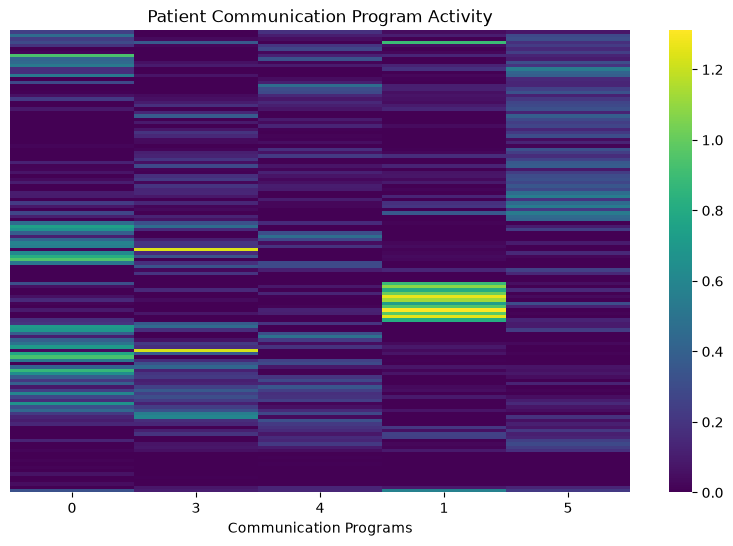

In [6]:
top_programs = (
    summary
    .query("FDR < 0.05")
    ["Program"]
    .tolist()
)


print(top_programs)


plt.figure(figsize=(10,6))

sns.heatmap(
    patient_df[top_programs],
    cmap="viridis",
    yticklabels=False
)

plt.title(
    "Patient Communication Program Activity"
)

plt.xlabel("Communication Programs")

plt.show()

In [7]:
top_features = {}


for program in program_features.index:

    top_features[program] = (
        program_features
        .loc[program]
        .sort_values(
            ascending=False
        )
        .head(20)
    )


for program, features in top_features.items():

    print("\n", program)

    display(features)


 0


MIF→TNFRSF14        0.833816
HLA-DRB5→CD4        0.801298
SELPLG→ITGB2        0.765446
LTB→TNFRSF1A        0.748398
HLA-F→LILRB1        0.743895
TNFSF13→TNFRSF1A    0.709546
SELPLG→SELL         0.695465
FADD→FAS            0.692404
TNFSF13→TNFRSF14    0.687429
APP→LRP10           0.686117
HLA-G→LILRB1        0.679178
HLA-C→CD8B          0.665340
HLA-DRB1→LAG3       0.661188
APP→CD74            0.657005
HLA-A→CD8B          0.656713
HLA-B→CD8B          0.650612
HLA-DPB1→LAG3       0.649947
HLA-E→CD8B          0.648092
HLA-DPA1→LAG3       0.646675
SERPINA1→LRP1       0.645696
Name: 0, dtype: float64


 1


VEGFA→NRP1           0.715767
CD99→CD81            0.699454
TXLNA→STX4           0.692531
TGFB1→CXCR4          0.679463
CALM1→PTPRA          0.677425
PTGS2→CAV1           0.675267
ICAM4→ITGAV          0.673443
TIMP2→CD44           0.673144
VEGFB→ADRB2          0.666223
HBEGF→CD44           0.665054
ICAM4→ITGB1          0.661910
VEGFA→NRP2           0.659908
TNFSF12→TNFRSF12A    0.656006
VEGFA→SIRPA          0.655944
GNAI2→CAV1           0.650799
TNFSF9→HLA-DPA1      0.647705
ACTR2→ADRB2          0.644524
VIM→CD44             0.644387
CALR→ITGAV           0.643400
BMP2→ENG             0.642595
Name: 1, dtype: float64


 2


...

GNAI2→C5AR1          0.705740
IFNA1→CR2            0.702251
RETN→CAP1            0.688587
COL4A6→CD47          0.683845
PSG9→DSCAM           0.678078
GNAI2→FPR1           0.672707
HDC→HRH3             0.667860
GNAI2→CHRM1          0.659498
CXCL13→CCR10         0.654158
CCL7→CCR10           0.646536
FGF6→SDC4            0.639026
LGALS9→CD47          0.629745
CLEC11A→ITGA11       0.625775
HLA-A→KIR2DL3        0.624029
CCL16→HRH4           0.616808
ICAM4→ITGA4          0.614878
HDC→HRH4             0.614124
FGF23→FGFR2          0.611278
DNAJB11→PRTG         0.609433
TNFSF13→TNFRSF13B    0.604495
Name: 7, dtype: float64


 8


CALM3→EGFR      0.388576
EFEMP1→EGFR     0.379334
COL5A1→SDC3     0.374170
DCN→EGFR        0.373638
VCAN→EGFR       0.371938
APP→TNFRSF21    0.371365
TNC→SDC4        0.367128
TNC→ITGA5       0.354937
APP→LRP1        0.348741
SFRP1→FZD6      0.345955
PSAP→LRP1       0.344882
GNAI2→EGFR      0.340555
CALR→LRP1       0.339385
RGMA→BMPR2      0.339374
LRPAP1→LRP1     0.339298
CALM3→AQP6      0.338231
FGF7→FGFR4      0.337387
TNC→SDC1        0.333174
FGF11→FGFR1     0.333006
ST6GAL1→EGFR    0.331601
Name: 8, dtype: float64


 9


HLA-DRB5→CD4     0.534955
HLA-F→LILRB1     0.524606
CD14→ITGA4       0.522918
APOE→LRP1        0.499360
C1QB→LRP1        0.473347
CD14→ITGB2       0.472756
CD14→ITGB1       0.458851
PSAP→LRP1        0.428357
LGALS9→LRP1      0.425405
SIRPA→CD47       0.421736
CD47→SIRPA       0.421736
HLA-DMB→CD4      0.414681
CD86→CD28        0.410261
CD28→CD86        0.410261
SERPINA1→LRP1    0.409226
HMGB1→TLR2       0.408322
ADAM10→TREM2     0.406725
HLA-A→LILRB1     0.406666
LRPAP1→LRP1      0.404910
HLA-C→LILRB1     0.404815
Name: 9, dtype: float64

In [8]:
feature_table = []

for program, features in top_features.items():

    for interaction, weight in features.items():

        feature_table.append(
            [
                program,
                interaction,
                weight
            ]
        )


feature_table = pd.DataFrame(
    feature_table,
    columns=[
        "Program",
        "Interaction",
        "Weight"
    ]
)


feature_table.to_csv(
    "data/outputs/program_top_LR_features.csv",
    index=False
)


feature_table.head()

,Program,Interaction,Weight
0,0,MIF→TNFRSF14,0.833816
1,0,HLA-DRB5→CD4,0.801298
2,0,SELPLG→ITGB2,0.765446
3,0,LTB→TNFRSF1A,0.748398
4,0,HLA-F→LILRB1,0.743895


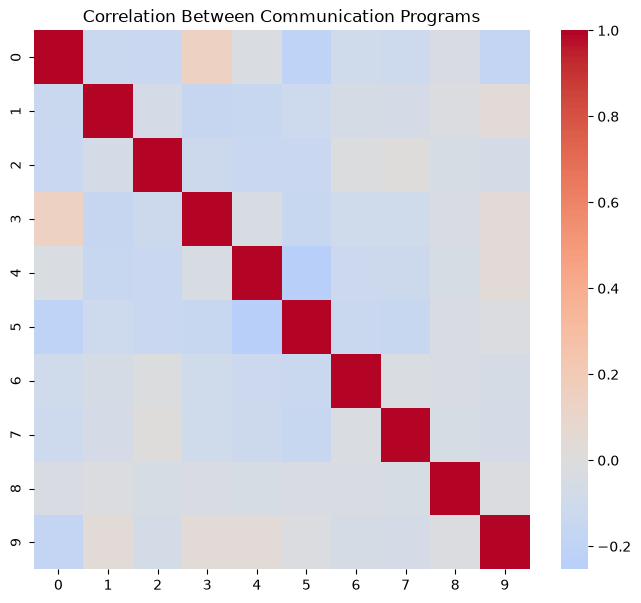

In [9]:
plt.figure(figsize=(8,7))

sns.heatmap(
    patient_programs.corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Between Communication Programs"
)

plt.show()

In [10]:
summary.to_csv(
    "data/outputs/program_biological_characterization.csv",
    index=False
)

print("Notebook 13 outputs saved.")

Notebook 13 outputs saved.
